# 🥗 Notebook 01 — Exploración del Dataset (EDA)

**Objetivo:** Entender el dataset Food-101 antes de entrenar cualquier modelo.

- Descargar Food-101 con `torchvision`
- Verificar distribución de clases (balance train/test)
- Visualizar ejemplos de imágenes
- Analizar distribución de resoluciones
- Preview del lookup nutricional


In [1]:
import sys
sys.path.append('..')  # para importar desde src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import datasets
from torch.utils.data import DataLoader
from pathlib import Path
from PIL import Image

from src.config import DATA_DIR, FOOD101_CLASSES, DEVICE
from src.transforms import get_train_transform, get_val_transform
from src.nutrition import get_nutrition

print(f'PyTorch: {torch.__version__}')
print(f'Device:  {DEVICE}')
print(f'Data dir: {DATA_DIR}')

PyTorch: 2.8.0
Device:  mps
Data dir: /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../data


## 📥 Parte 1 — Descarga de Food-101

`torchvision.datasets.Food101` descarga y descomprime automáticamente (~5 GB).
Si ya está descargado, `download=True` lo detecta y no vuelve a descargar.


In [2]:
# Descarga Food-101 — puede tardar varios minutos según la conexión
train_dataset = datasets.Food101(
    root=str(DATA_DIR),
    split='train',
    transform=get_val_transform(),  # sin augmentación para EDA
    download=True,
)

test_dataset = datasets.Food101(
    root=str(DATA_DIR),
    split='test',
    transform=get_val_transform(),
    download=True,
)

print(f'Train: {len(train_dataset):,} imágenes')
print(f'Test:  {len(test_dataset):,} imágenes')
print(f'Clases: {len(train_dataset.classes)}')

Train: 75,750 imágenes
Test:  25,250 imágenes
Clases: 101


## 📊 Parte 2 — Distribución de Clases


Train — min: 750, max: 750, promedio: 750
Test  — min: 250,  max: 250,  promedio: 250


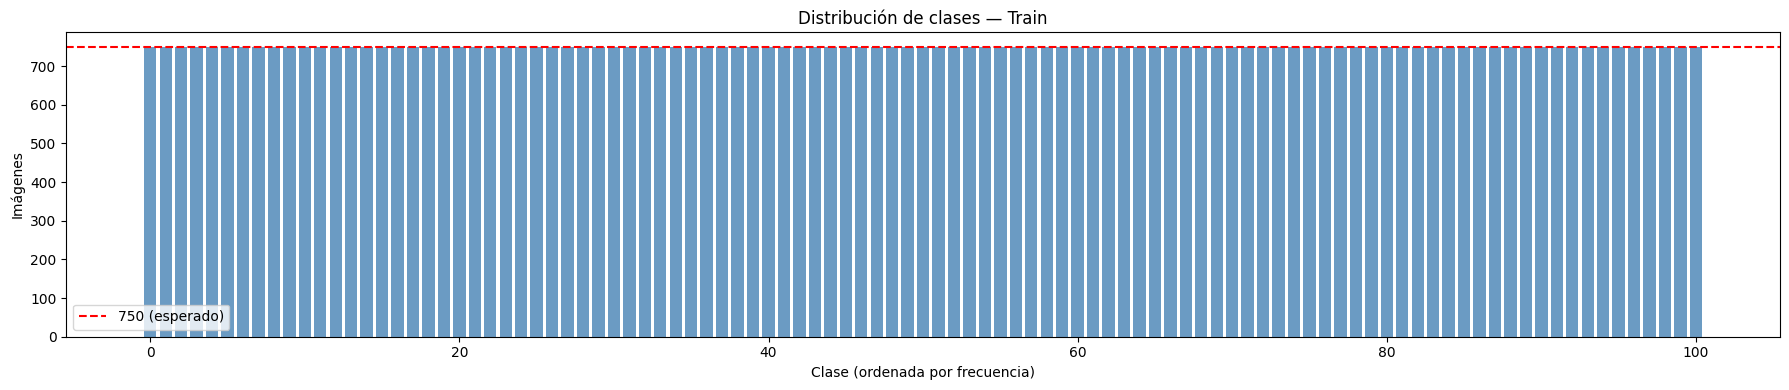

In [3]:
# Verificar que el dataset está perfectamente balanceado: 750 train / 250 test por clase                                                                                                                 
train_counts = np.bincount(train_dataset._labels)                                                                                                                                                        
test_counts  = np.bincount(test_dataset._labels)                                                                                                                                                         
                                                                                                                                                                                                           
print(f'Train — min: {train_counts.min()}, max: {train_counts.max()}, promedio: {train_counts.mean():.0f}')                                                                                              
print(f'Test  — min: {test_counts.min()},  max: {test_counts.max()},  promedio: {test_counts.mean():.0f}')
                                                                                                                                                                                                           
 # Gráfico: conteo de imágenes por clase (solo train)                                                                                                                                                     
fig, ax = plt.subplots(figsize=(18, 4))                                                                                                                                                                  
ax.bar(range(len(train_counts)), sorted(train_counts, reverse=True), color='steelblue', alpha=0.8)                                                                                                       
ax.set(xlabel='Clase (ordenada por frecuencia)', ylabel='Imágenes', title='Distribución de clases — Train')                                                                                              
ax.axhline(y=750, color='red', linestyle='--', label='750 (esperado)')                                                                                                                                   
ax.legend()                                                                                                                                                                                              
plt.tight_layout()                                                                                                                                                                                       
plt.show()

## 🖼️ Parte 3 — Grid Visual de Ejemplos


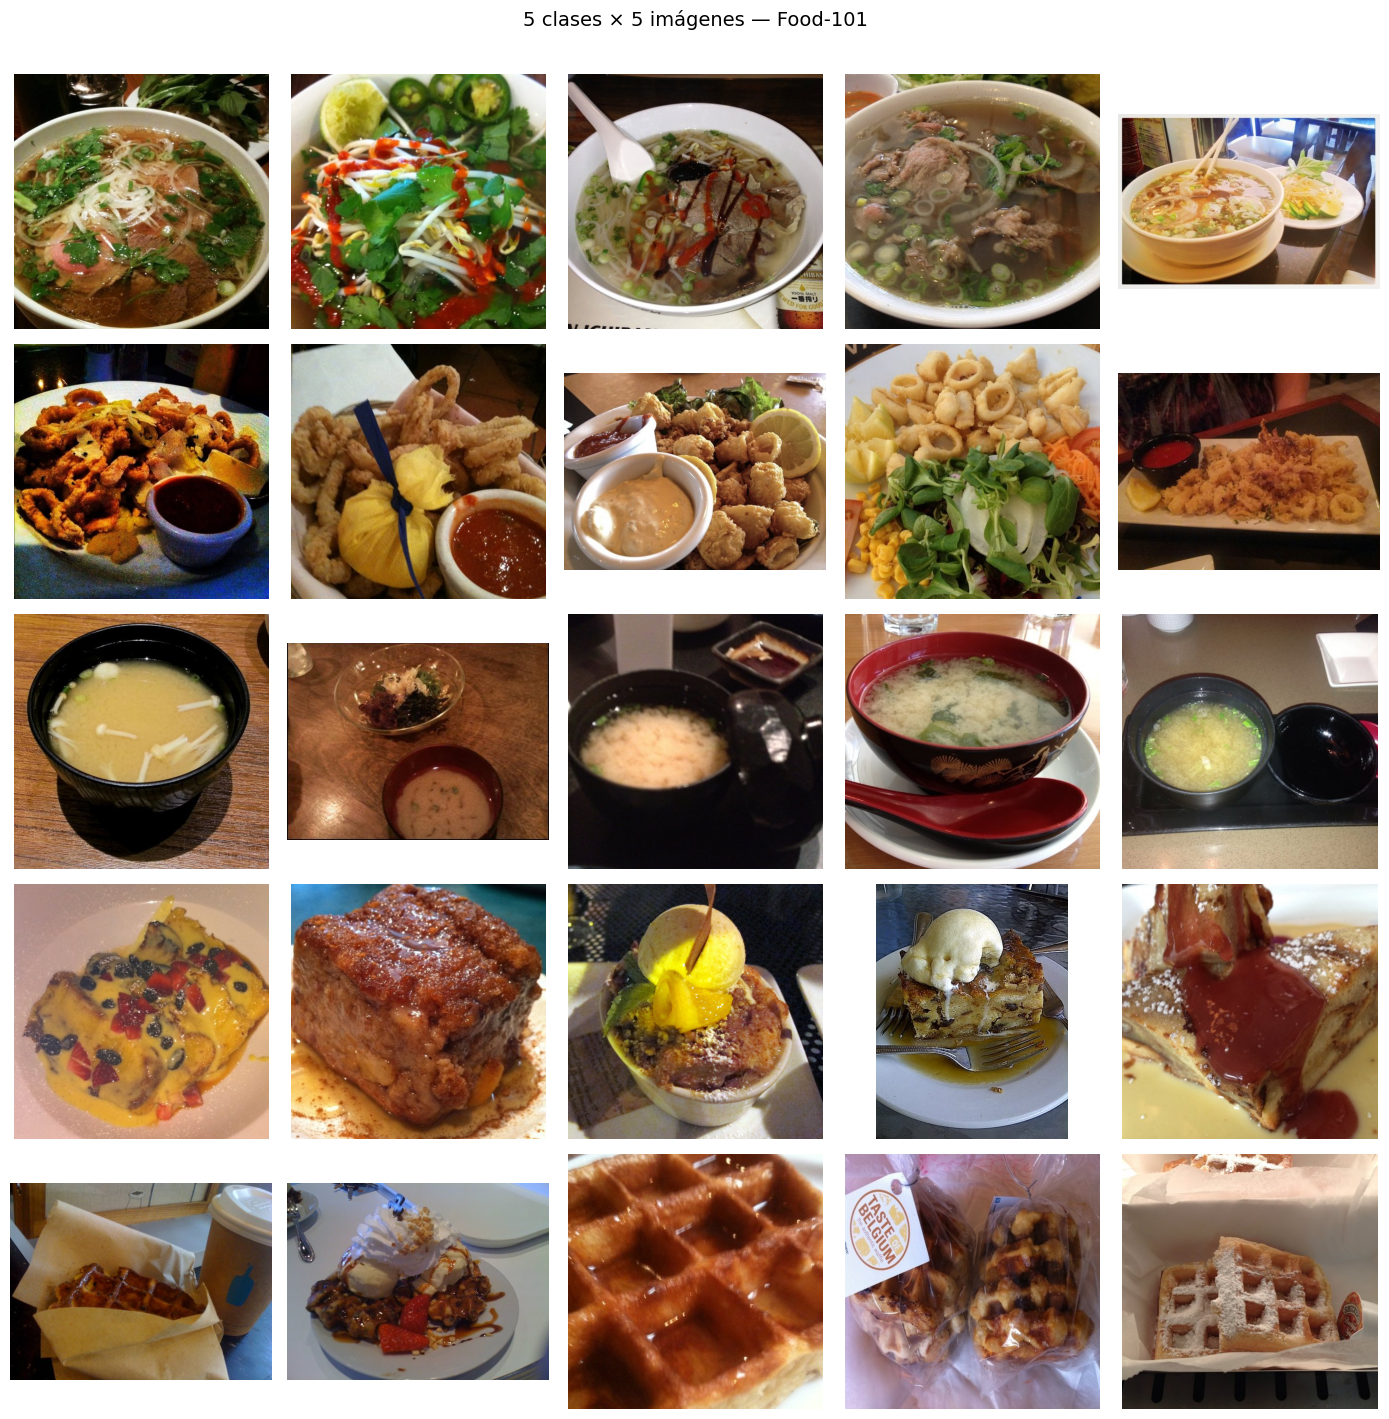

In [5]:
# Dataset sin transform para visualizar imágenes originales
raw_dataset = datasets.Food101(
    root=str(DATA_DIR),
    split='train',
    transform=None,
    download=False,
)

rng = np.random.default_rng(seed=42)
sample_classes = rng.choice(len(FOOD101_CLASSES), size=5, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(14, 14))
fig.suptitle('5 clases × 5 imágenes — Food-101', fontsize=14, y=1.01)


for row_idx, class_idx in enumerate(sample_classes):
    class_name = FOOD101_CLASSES[class_idx]
    # Obtener índices de esa clase
    indices = [i for i, t in enumerate(raw_dataset._labels) if t == class_idx]
    selected = rng.choice(indices, size=5, replace=False)
    
    for col_idx, img_idx in enumerate(selected):
        img, _ = raw_dataset[img_idx]
        axes[row_idx, col_idx].imshow(img)
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(class_name.replace('_', ' '), fontsize=9, labelpad=5)

plt.tight_layout()
plt.show()

## 📐 Parte 4 — Distribución de Resoluciones


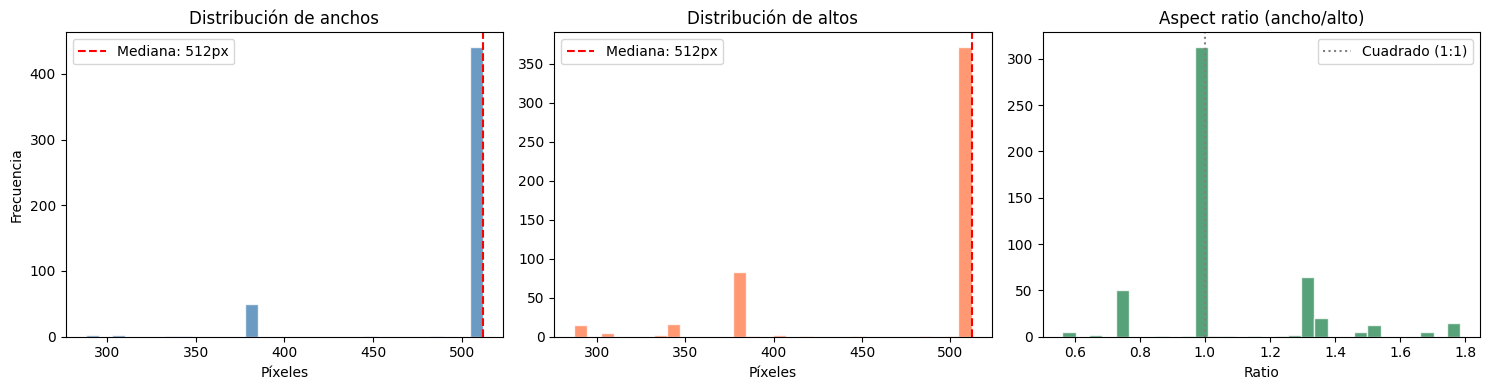

Ancho  — media: 496px, std: 45px
Alto   — media: 475px, std: 67px


In [6]:
# Muestreo de resoluciones (500 imágenes aleatorias para agilizar)
sample_idx = rng.choice(len(raw_dataset), size=500, replace=False)

widths, heights = [], []
for idx in sample_idx:
    img, _ = raw_dataset[idx]
    widths.append(img.width)
    heights.append(img.height)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths,  bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set(title='Distribución de anchos', xlabel='Píxeles', ylabel='Frecuencia')
axes[0].axvline(np.median(widths), color='red', linestyle='--', label=f'Mediana: {int(np.median(widths))}px')
axes[0].legend()

axes[1].hist(heights, bins=30, color='coral',    alpha=0.8, edgecolor='white')
axes[1].set(title='Distribución de altos',   xlabel='Píxeles')
axes[1].axvline(np.median(heights), color='red', linestyle='--', label=f'Mediana: {int(np.median(heights))}px')
axes[1].legend()

aspect_ratios = np.array(widths) / np.array(heights)
axes[2].hist(aspect_ratios, bins=30, color='seagreen', alpha=0.8, edgecolor='white')
axes[2].set(title='Aspect ratio (ancho/alto)', xlabel='Ratio')
axes[2].axvline(1.0, color='gray', linestyle=':', label='Cuadrado (1:1)')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Ancho  — media: {np.mean(widths):.0f}px, std: {np.std(widths):.0f}px')
print(f'Alto   — media: {np.mean(heights):.0f}px, std: {np.std(heights):.0f}px')

## 🥦 Parte 5 — Preview del Lookup Nutricional


Categorías con datos nutricionales: 101/101

Rango de calorías por 100g:
  Mínimo: 40 kcal (miso_soup)
  Máximo: 462 kcal (foie_gras)
  Promedio: 231 kcal


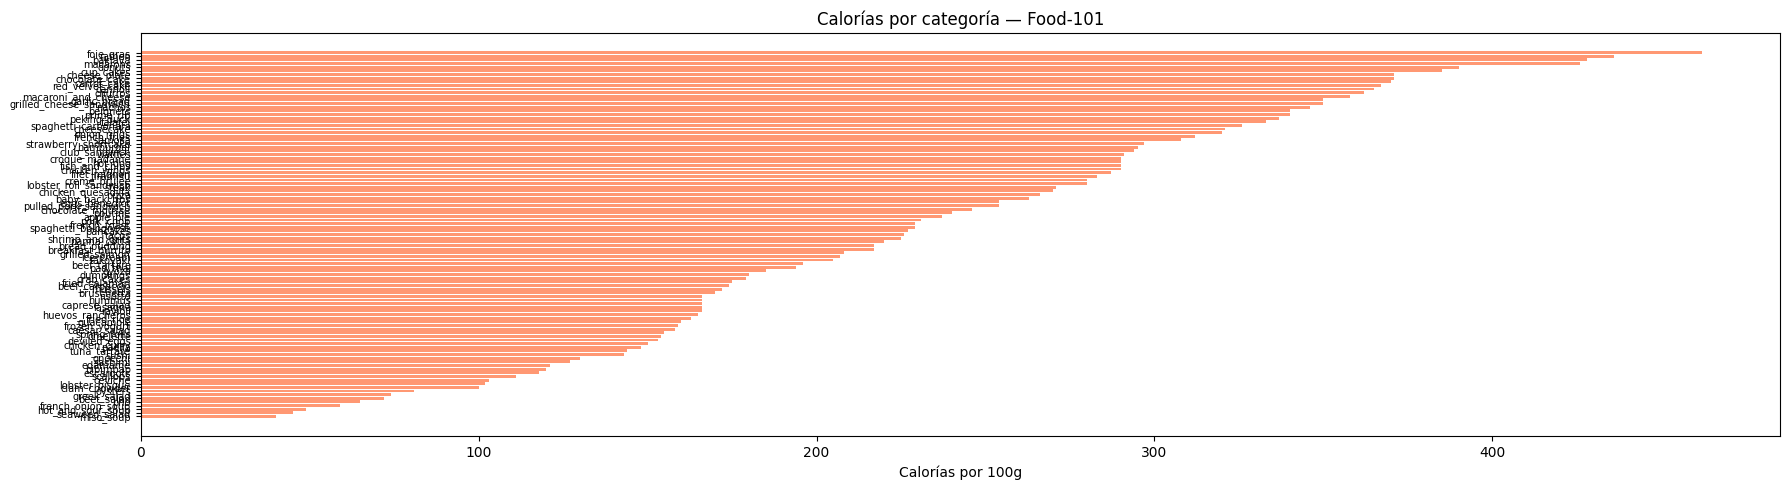

In [9]:
# Construir tabla de nutrición para las 101 categorías
rows = []
for cls in FOOD101_CLASSES:
    n = get_nutrition(cls)
    if n:
        rows.append({'clase': cls, **n})

df = pd.DataFrame(rows).set_index('clase')

print(f'Categorías con datos nutricionales: {len(df)}/101')
print(f'\nRango de calorías por 100g:')
print(f'  Mínimo: {df["calories"].min()} kcal ({df["calories"].idxmin()})')
print(f'  Máximo: {df["calories"].max()} kcal ({df["calories"].idxmax()})')
print(f'  Promedio: {df["calories"].mean():.0f} kcal')

# Gráfico: calorías por categoría ordenadas
fig, ax = plt.subplots(figsize=(18, 5))
df_sorted = df.sort_values('calories')
ax.barh(df_sorted.index, df_sorted['calories'], color='coral', alpha=0.8)
ax.set(xlabel='Calorías por 100g', title='Calorías por categoría — Food-101')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

In [10]:
# Top-10 más calóricas y menos calóricas
print('=== TOP 10 más calóricas (por 100g) ===')
print(df.sort_values('calories', ascending=False).head(10)[['calories', 'protein_g', 'carbs_g', 'fat_g', 'portion_g']].to_string())

print('\n=== TOP 10 menos calóricas (por 100g) ===')
print(df.sort_values('calories').head(10)[['calories', 'protein_g', 'carbs_g', 'fat_g', 'portion_g']].to_string())

=== TOP 10 más calóricas (por 100g) ===
                 calories  protein_g  carbs_g  fat_g  portion_g
clase                                                          
foie_gras             462       11.0      4.7   43.0         80
ramen                 436       21.0     57.0   14.0        500
baklava               428        5.6     52.0   23.0         80
macarons              426        5.5     64.0   17.0         50
donuts                390        5.0     48.0   20.0         75
cup_cakes             385        4.5     56.0   17.0         80
chocolate_cake        371        5.0     53.0   16.0        100
cheese_plate          371       23.0      1.3   30.0        100
carrot_cake           370        4.5     52.0   17.0        100
red_velvet_cake       367        4.5     54.0   15.0        100

=== TOP 10 menos calóricas (por 100g) ===
                   calories  protein_g  carbs_g  fat_g  portion_g
clase                                                            
miso_soup        

---
## ❓ Preguntas de reflexión

1. **¿El dataset está balanceado?** ¿Qué implicancias tiene para el entrenamiento?
2. **¿Qué resolución predomina?** ¿Es necesario hacer un resize antes de entrenar?
3. **¿Cuál es el rango calórico?** ¿Cuánto impacta un error de clasificación entre categorías adyacentes?
4. **¿Qué categorías son visualmente similares** y podrían confundir al modelo?
